In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from scipy.stats import ks_2samp

import warnings
warnings.filterwarnings('ignore')

from astropy.coordinates import SkyCoord  # High-level coordinates
from astropy.coordinates import ICRS, Galactic, FK4, FK5  # Low-level frames
from astropy.coordinates import Angle, Latitude, Longitude  # Angles
import astropy.units as u
import matplotlib as mpl
from matplotlib import pyplot as plt
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
from matplotlib.ticker import FormatStrFormatter
import seaborn as sns
palette = 'viridis'
font = {'family': 'serif', 'color':  'black', 'weight': 'normal','size': 14}

In [2]:
df = pd.read_csv('Dados/results.csv', index_col = 'Cluster')
benchmark_subsample = pd.read_csv('Dados/benchmark_subsample.csv')
data = pd.read_csv('Dados/data.csv', index_col ='Cluster')

In [3]:
df.FeH.describe()

count    771.000000
mean      -0.035634
std        0.107249
min       -0.373000
25%       -0.113500
50%       -0.036000
75%        0.032000
max        0.426000
Name: FeH, dtype: float64

In [4]:
def classificar_metalicidade(m):
    if m < -0:
        return '[Fe/H]<0'
    else:
        return '[Fe/H]>0'
aux = data.copy(deep=True)
aux['FeH_class'] = aux['FeH'].apply(classificar_metalicidade)
df['FeH_class'] = df['FeH'].apply(classificar_metalicidade)

In [5]:
aux  = aux[aux.q>0]

In [6]:
aux['FeH_class'].value_counts()

FeH_class
[Fe/H]<0    54321
[Fe/H]>0    32233
Name: count, dtype: int64

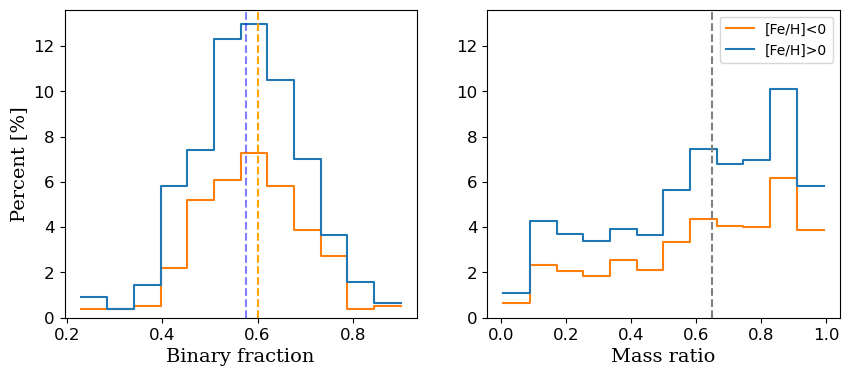

In [7]:
fig, axs = plt.subplots(1,2, figsize=(10,4), sharey=True)


sns.histplot(data=df, x='bin_frac', hue='FeH_class', bins=12,
                   element='step', fill=None, stat='percent', legend=False, ax=axs[0], hue_order=['[Fe/H]<0', '[Fe/H]>0'])

axs[0].axvline(df[df.FeH<-0.1].bin_frac.median(), color='orange', linestyle='--')
axs[0].axvline(df[df.FeH>=-0.1].bin_frac.median(), color='b', linestyle='--', alpha=0.5)

sns.histplot(data=aux, x='q', hue='FeH_class', bins=12, hue_order=['[Fe/H]<0', '[Fe/H]>0'],
                   element='step', fill=None, stat='percent', legend=False, ax=axs[1])

axs[1].axvline(aux[aux.FeH<-0.1].q.median(), color='gray', linestyle='--')


axs[0].set_xlabel('Binary fraction', fontdict=font)
axs[1].set_xlabel('Mass ratio', fontdict=font)
axs[0].set_ylabel('Percent [%]', fontdict=font)
axs[1].legend(title='', labels=['[Fe/H]<0', '[Fe/H]>0']) 
axs[0].tick_params(labelleft=True, labelbottom=True, labelsize=12)
axs[1].tick_params(labelleft=True, labelbottom=True, labelsize=12)
plt.savefig('Figures/hist_mass_ratio_metalicidade.png', bbox_inches='tight', dpi=300)
plt.show()

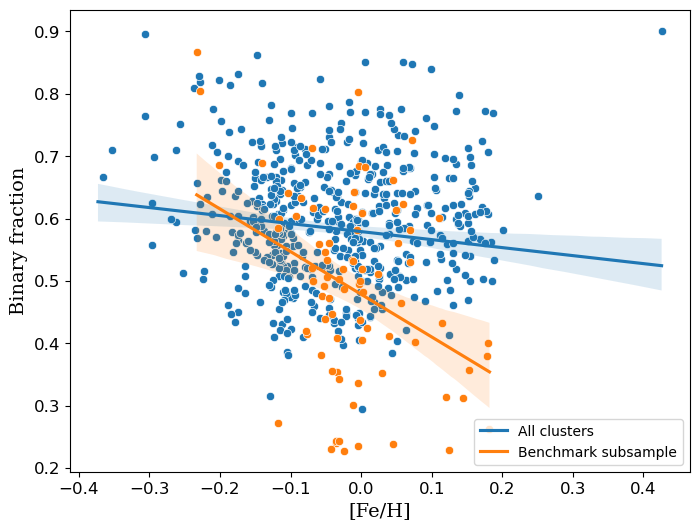

In [10]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=df[(df.dist>=1)], x='FeH', y= 'bin_frac',)
sns.regplot(data=df, x='FeH', y='bin_frac',
            scatter=False, label='All clusters', color='tab:blue',)


sns.scatterplot(data=df[(df.dist<1) & (df.Av<.5)], x='FeH', y= 'bin_frac',)
sns.regplot(data=benchmark_subsample, x='FeH', y='bin_frac', label =r'Benchmark subsample', scatter=False, color='tab:orange')


plt.xlabel('[Fe/H]', fontdict=font)
plt.ylabel('Binary fraction', fontdict=font)
plt.legend(loc ='lower right')
plt.tick_params(labelleft=True, labelbottom=True, labelsize=12)
plt.savefig('Figures/dist_fb_metalicidade.png',bbox_inches='tight', dpi=300)
plt.show()



In [12]:
benchmark_subsample[['FeH', 'bin_frac']].corr()

,FeH,bin_frac
FeH,1.000000,-0.120556
bin_frac,-0.120556,1.000000
